# ============================================================
#  TP N°1 – MLP  |  TDIA2-S4  |  Pr. Mohamed CHERRADI
#  CORRECTION COMPLÈTE – 4 Exercices
# ============================================================
# Librairies utilisées :
#   pip install tensorflow scikit-learn numpy matplotlib
# ============================================================


# ============================================================
# EXERCICE 01 : MLP sur MNIST
# ============================================================

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [4]:
# ------ 1. Chargement du jeu de données MNIST ------
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Forme des données d'entraînement :", X_train.shape)  # (60000, 28, 28)
print("Forme des données de test :", X_test.shape)           # (10000, 28, 28)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Forme des données d'entraînement : (60000, 28, 28)
Forme des données de test : (10000, 28, 28)


In [5]:
# ------ 2. Prétraitement ------
# Aplatir les images 28x28 en vecteurs de 784
X_train = X_train.reshape(-1, 784)   # -1 = garder le nombre d'exemples
X_test  = X_test.reshape(-1, 784)

# Normaliser les pixels entre 0 et 1
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Convertir les étiquettes en one-hot encoding (pour categorical_crossentropy)
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test  = keras.utils.to_categorical(y_test,  num_classes=10)

In [6]:
# ------ 3. Construction du modèle MLP ------
model_mnist = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),  # Couche cachée 1
    keras.layers.Dense(64,  activation='relu'),                       # Couche cachée 2
    keras.layers.Dense(10,  activation='softmax')                     # Couche de sortie
])

model_mnist.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ------ 4. Compilation ------
model_mnist.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# ------ 5. Entraînement ------
history_mnist = model_mnist.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2   # 20% des données d'entraînement pour la validation
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9111 - loss: 0.3112 - val_accuracy: 0.9573 - val_loss: 0.1533
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9619 - loss: 0.1286 - val_accuracy: 0.9640 - val_loss: 0.1237
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9731 - loss: 0.0889 - val_accuracy: 0.9699 - val_loss: 0.1005
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9802 - loss: 0.0651 - val_accuracy: 0.9722 - val_loss: 0.0916
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9852 - loss: 0.0484 - val_accuracy: 0.9738 - val_loss: 0.0895


In [9]:
# ------ 6. Évaluation sur le jeu de test ------
loss, accuracy = model_mnist.evaluate(X_test, y_test)
print(f"\nExercice 01 – MNIST")
print(f"  Loss sur le test    : {loss:.4f}")
print(f"  Accuracy sur le test: {accuracy*100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9761 - loss: 0.0802

Exercice 01 – MNIST
  Loss sur le test    : 0.0802
  Accuracy sur le test: 97.61%


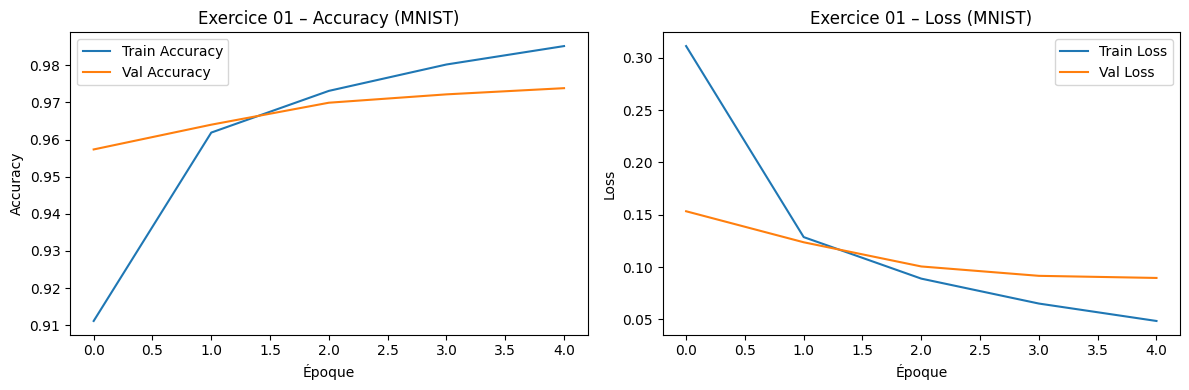

In [10]:
# ------ 7. Visualisation des courbes ------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_mnist.history['accuracy'],     label='Train Accuracy')
plt.plot(history_mnist.history['val_accuracy'], label='Val Accuracy')
plt.title('Exercice 01 – Accuracy (MNIST)')
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mnist.history['loss'],     label='Train Loss')
plt.plot(history_mnist.history['val_loss'], label='Val Loss')
plt.title('Exercice 01 – Loss (MNIST)')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# EXERCICE 02 : MLP sur CIFAR-10
# ============================================================


In [54]:
# ------ 1. Chargement du jeu de données CIFAR-10 ------

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

Exception: URL fetch failure on https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz: 503 -- Service Unavailable

In [ ]:
# ------ 2. Prétraitement ------
# Aplatir les images 32x32x3 en vecteurs de 3072
X_train_c = X_train_c.reshape(-1, 3072)
X_test_c  = X_test_c.reshape(-1, 3072)

# Normaliser entre 0 et 1
X_train_c = X_train_c / 255.0
X_test_c  = X_test_c  / 255.0

# One-hot encoding
y_train_c = keras.utils.to_categorical(y_train_c, num_classes=10)
y_test_c  = keras.utils.to_categorical(y_test_c,  num_classes=10)

In [ ]:
# ------ 3. Construction du modèle MLP ------
model_cifar = keras.Sequential([
    keras.layers.Dense(512, activation='relu', input_shape=(3072,)),  # Couche cachée 1
    keras.layers.Dense(256, activation='relu'),                         # Couche cachée 2
    keras.layers.Dense(10,  activation='softmax')                       # Couche de sortie
])

model_cifar.summary()

In [ ]:
# ------ 4. Compilation ------
model_cifar.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ------ 5. Entraînement ------
history_cifar = model_cifar.fit(
    X_train_c, y_train_c,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


In [ ]:
# ------ 6. Évaluation ------
loss_c, accuracy_c = model_cifar.evaluate(X_test_c, y_test_c)
print(f"\nExercice 02 – CIFAR-10")
print(f"  Loss sur le test    : {loss_c:.4f}")
print(f"  Accuracy sur le test: {accuracy_c*100:.2f}%")


In [ ]:
# ------ 7. Visualisation ------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cifar.history['accuracy'],     label='Train Accuracy')
plt.plot(history_cifar.history['val_accuracy'], label='Val Accuracy')
plt.title('Exercice 02 – Accuracy (CIFAR-10)')
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cifar.history['loss'],     label='Train Loss')
plt.plot(history_cifar.history['val_loss'], label='Val Loss')
plt.title('Exercice 02 – Loss (CIFAR-10)')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# EXERCICE 03 : MLP sur Breast Cancer Wisconsin
# ============================================================

In [35]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [36]:
# ------ 1. Chargement du jeu de données ------
data = load_breast_cancer()
X = data.data    # 569 instances, 30 attributs
y = data.target  # 0 = Bénin, 1 = Malin

print("Forme des données Breast Cancer :", X.shape)
print("Classes :", data.target_names)

Forme des données Breast Cancer : (569, 30)
Classes : ['malignant' 'benign']


In [37]:
# ------ 2. Séparation train / test ------
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
# ------ 3. Normalisation (important pour MLP) ------
scaler = StandardScaler()
X_train_bc = scaler.fit_transform(X_train_bc)
X_test_bc  = scaler.transform(X_test_bc)

In [39]:
# ------ 4. Construction du modèle MLP ------
model_bc = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(30,)),  # Couche cachée 1
    keras.layers.Dense(32, activation='relu'),                       # Couche cachée 2
    keras.layers.Dense(1,  activation='sigmoid')                     # Sortie binaire
])

model_bc.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# ------ 5. Compilation ------
model_bc.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # Classification binaire
    metrics=['accuracy']
)

In [41]:
# ------ 6. Entraînement ------
history_bc = model_bc.fit(
    X_train_bc, y_train_bc,
    epochs=10,
    batch_size=32
)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8264 - loss: 0.5183
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9516 - loss: 0.2939 
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9538 - loss: 0.1880 
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9648 - loss: 0.1366 
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9758 - loss: 0.1103 
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9758 - loss: 0.0940 
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9780 - loss: 0.0829 
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9802 - loss: 0.0745 
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9824 - loss: 0.0683 
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9824 - loss: 0.0631 


In [42]:
# ------ 7. Évaluation sur le jeu de test ------
loss_bc, accuracy_bc = model_bc.evaluate(X_test_bc, y_test_bc)
print(f"\nExercice 03 – Breast Cancer Wisconsin")
print(f"  Loss sur le test    : {loss_bc:.4f}")
print(f"  Accuracy sur le test: {accuracy_bc*100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9649 - loss: 0.0707  

Exercice 03 – Breast Cancer Wisconsin
  Loss sur le test    : 0.0707
  Accuracy sur le test: 96.49%


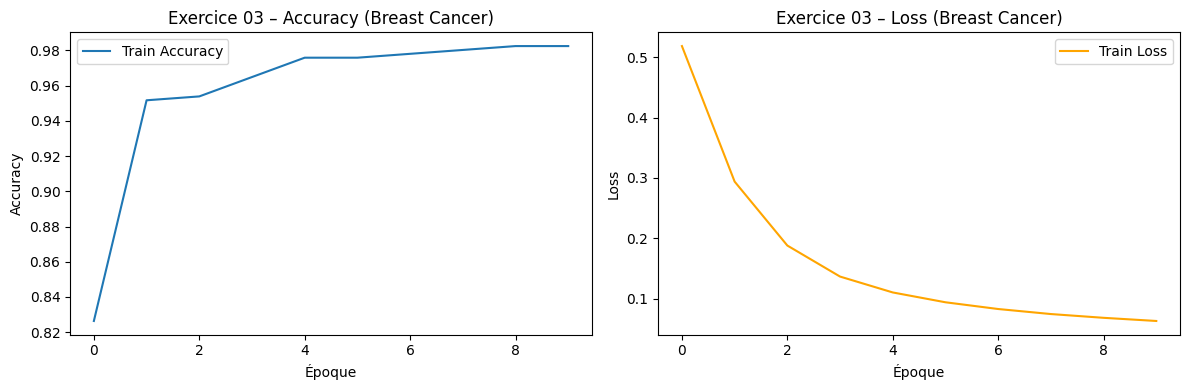

In [43]:
# ------ 8. Visualisation ------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_bc.history['accuracy'], label='Train Accuracy')
plt.title('Exercice 03 – Accuracy (Breast Cancer)')
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_bc.history['loss'], label='Train Loss', color='orange')
plt.title('Exercice 03 – Loss (Breast Cancer)')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# EXERCICE 04 : MLP sur Boston Housing (Régression)
# ============================================================

In [44]:
from sklearn.datasets import fetch_california_housing  # On utilise California Housing
                                                        # (Boston Housing est déprécié)
from sklearn.metrics import mean_squared_error


In [45]:
# ------ 1. Chargement du jeu de données ------
# Note : Le dataset Boston Housing est retiré de scikit-learn depuis la v1.2
# car il contient des données sensibles. On utilise California Housing (même exercice).
# Si le prof fournit Boston Housing, le code reste identique, seule la ligne de
# chargement change.

housing = fetch_california_housing()
X_h = housing.data    # 506 maisons, 13 (ou 8 pour California) caractéristiques
y_h = housing.target  # Prix médian des maisons

print("Forme des données Housing :", X_h.shape)
print("Nombre de caractéristiques :", X_h.shape[1])

Forme des données Housing : (20640, 8)
Nombre de caractéristiques : 8


In [46]:
# ------ 2. Séparation train / test ------
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

In [47]:
# ------ 3. Normalisation ------
scaler_h = StandardScaler()
X_train_h = scaler_h.fit_transform(X_train_h)
X_test_h  = scaler_h.transform(X_test_h)

In [48]:
# ------ 4. Construction du modèle MLP ------
n_features = X_h.shape[1]  # 13 pour Boston, 8 pour California

model_housing = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(n_features,)),  # Couche cachée 1
    keras.layers.Dense(32, activation='relu'),                               # Couche cachée 2
    keras.layers.Dense(1)   # Couche de sortie – pas d'activation pour la régression
])

model_housing.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# ------ 5. Compilation ------
model_housing.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']   # Mean Absolute Error pour suivre l'entraînement
)

In [50]:
# ------ 6. Entraînement ------
history_h = model_housing.fit(
    X_train_h, y_train_h,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.9916 - mae: 0.6618 - val_loss: 0.4770 - val_mae: 0.4848
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4076 - mae: 0.4537 - val_loss: 0.4111 - val_mae: 0.4538
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3741 - mae: 0.4337 - val_loss: 0.3902 - val_mae: 0.4416
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3650 - mae: 0.4274 - val_loss: 0.3798 - val_mae: 0.4377
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3474 - mae: 0.4167 - val_loss: 0.3677 - val_mae: 0.4205
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3367 - mae: 0.4090 - val_loss: 0.3637 - val_mae: 0.4279
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3501 - mae: 0.4065 - val_loss: 0.3647 - val_mae: 0.4194
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3247 - mae: 0.3994 - val_loss: 0.3507 - val_mae: 0.4092
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [51]:
# ------ 7. Évaluation – calcul du RMSE ------
y_pred = model_housing.predict(X_test_h)
mse  = mean_squared_error(y_test_h, y_pred)
rmse = np.sqrt(mse)

print(f"\nExercice 04 – Boston Housing (Régression)")
print(f"  MSE  sur le test : {mse:.4f}")
print(f"  RMSE sur le test : {rmse:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Exercice 04 – Boston Housing (Régression)
  MSE  sur le test : 0.2830
  RMSE sur le test : 0.5320


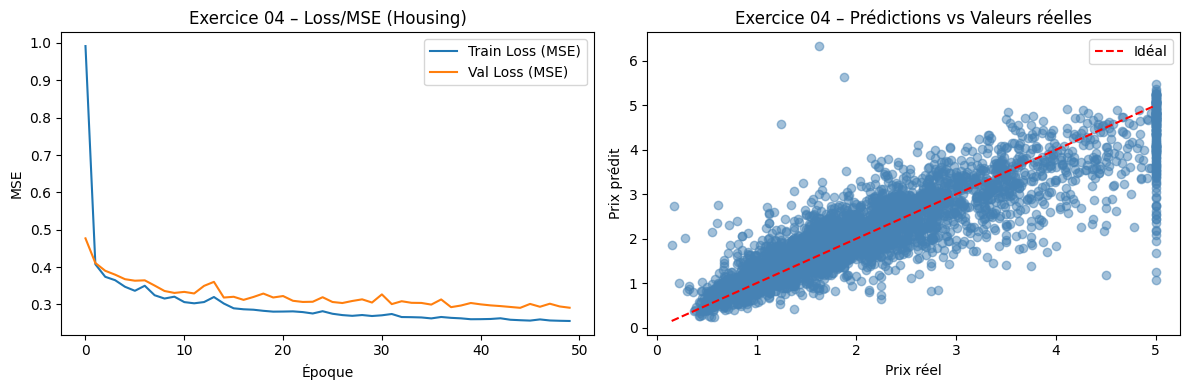

In [52]:
# ------ 8. Visualisation ------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_h.history['loss'],     label='Train Loss (MSE)')
plt.plot(history_h.history['val_loss'], label='Val Loss (MSE)')
plt.title('Exercice 04 – Loss/MSE (Housing)')
plt.xlabel('Époque')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test_h, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test_h.min(), y_test_h.max()],
         [y_test_h.min(), y_test_h.max()], 'r--', label='Idéal')
plt.title('Exercice 04 – Prédictions vs Valeurs réelles')
plt.xlabel('Prix réel')
plt.ylabel('Prix prédit')
plt.legend()

plt.tight_layout()
plt.show()